# Sesión 4: Regresión Lineal Simple y Múltiple

**Objetivos:**
- Entender la diferencia conceptual entre regresión simple y múltiple.
- Saber preparar los datos para un modelo de regresión, incluyendo el manejo de variables categóricas.
- Implementar y entrenar un modelo de `LinearRegression` con `scikit-learn`.
- Evaluar el rendimiento del modelo con métricas clave como $R^2$, MAE y RMSE.
- Interpretar los coeficientes del modelo y visualizar sus resultados para explicar su comportamiento.

## 1. ¿Qué es la Regresión?

En Machine Learning, usamos la regresión cuando queremos predecir un valor **numérico continuo**. Por ejemplo:
- Predecir el precio de una casa.
- Estimar la temperatura de mañana.
- Predecir el coste del seguro médico de una persona (¡nuestro caso de hoy!).

La **Regresión Lineal** es el modelo más sencillo para esta tarea. Asume que existe una relación lineal entre las variables de entrada (X, también llamadas *features* o predictoras) y la variable de salida (y, también llamada *target* o variable dependiente). La fórmula que busca aprender es la de una línea (o un hiperplano en más dimensiones):

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$

- $\beta_0$ es el **intercepto** (el valor de $y$ cuando todas las $x$ son cero).
- $\beta_1, \beta_2, ...$ son los **coeficientes** de cada variable. Nos dicen cuánto cambia $y$ por cada unidad que aumenta la $x$ correspondiente, manteniendo las demás constantes.

- **Regresión Lineal Simple:** Solo tenemos una variable de entrada ($x_1$).
- **Regresión Lineal Múltiple:** Usamos varias variables de entrada ($x_1, x_2, ..., x_n$).

In [1]:
# Importamos las librerías fundamentales que usaremos en la sesión
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos seaborn para que los gráficos se vean un poco más atractivos
sns.set_theme(style="whitegrid")

## 2. Carga y Exploración de Datos (EDA)

Vamos a trabajar con el dataset "Medical Cost Personal Datasets", que se encuentra en Kaggle. Contiene información anónima sobre los asegurados de una compañía y su objetivo es predecir los `charges` (costes médicos facturados).

Las columnas son:
- `age`: edad del beneficiario.
- `sex`: sexo del beneficiario.
- `bmi`: índice de masa corporal.
- `children`: número de hijos cubiertos por el seguro.
- `smoker`: si la persona es fumadora o no.
- `region`: la región de residencia en EEUU.
- `charges`: los costes médicos individuales facturados por el seguro (nuestra **variable objetivo**).

In [2]:
# Cargamos los datos directamente desde una URL para que sea reproducible
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

In [3]:
# Damos un primer vistazo a los datos
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:
print("\nInformación general y tipos de datos:")
df.info()


Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
print("\nEstadísticas descriptivas de las columnas numéricas:")
print(df.describe())


Estadísticas descriptivas de las columnas numéricas:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


### Análisis Visual

Antes de construir un modelo, un buen analista siempre "mira" sus datos. Las visualizaciones nos dan una intuición clave.

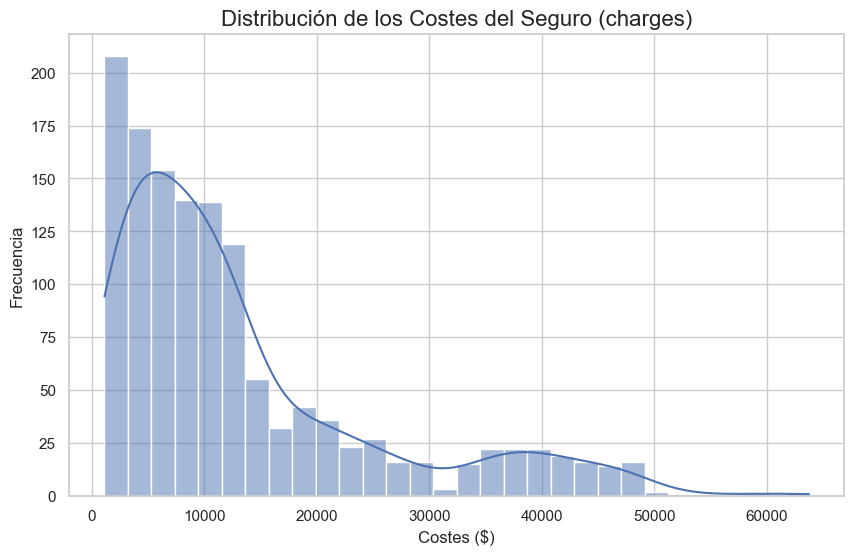

In [6]:
# 1. ¿Cómo se distribuyen los costes (nuestra variable objetivo)?
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribución de los Costes del Seguro (charges)', fontsize=16)
plt.xlabel('Costes ($)')
plt.ylabel('Frecuencia')
plt.show()

# Reflexión: Vemos que la mayoría de la gente tiene costes bajos, con una larga cola hacia la derecha (right-skewed).
# Esto nos dice que hay un grupo de personas con costes muy, muy altos. ¿Quiénes serán?

## 3. Preparación de Datos

Los modelos de machine learning no entienden de texto ('male', 'female', 'yes', 'no'). Necesitamos convertir las variables categóricas en números. La técnica estándar es **One-Hot Encoding**. `pandas` nos lo pone muy fácil con la función `get_dummies`.

In [7]:
# Convertimos las variables categóricas en numéricas
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# drop_first=True evita la multicolinealidad. Por ejemplo, si tenemos sex_male, no necesitamos
# una columna sex_female, porque si sex_male es 0, sabemos que es female.

print("Dataset después de One-Hot Encoding:")
print(df_encoded.head())

Dataset después de One-Hot Encoding:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


### Matriz de Correlación

Ahora que todo es numérico, podemos calcular la correlación entre todas las variables. Una matriz de correlación visualizada con un mapa de calor (heatmap) es una herramienta potentísima para intuir qué variables serán más importantes para predecir `charges`.

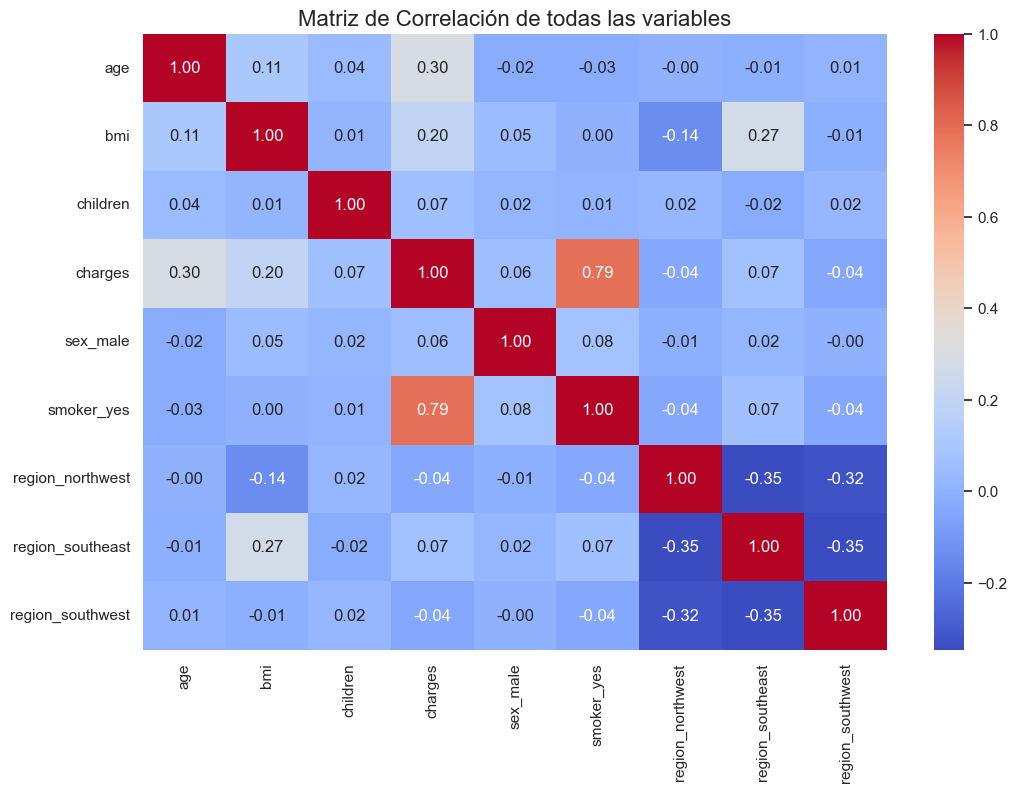

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de todas las variables', fontsize=16)
plt.show()

# Interpretación: Buscamos en la fila/columna 'charges' los colores más intensos (rojos o azules).
# 'smoker_yes' tiene una correlación muy alta (0.79), 'age' (0.30) y 'bmi' (0.20) también parecen relevantes.
# ¡Esto ya nos da pistas para nuestro modelo!

## 4. Modelo de Regresión Lineal Múltiple (Ejemplo Guiado)

Vamos a construir nuestro primer modelo para predecir `charges` usando todas las variables disponibles.

**Pasos clave:**
1.  **Separar X e y**: `X` contiene las variables predictoras, `y` contiene la variable objetivo.
2.  **Dividir en train/test**: Usamos una parte de los datos para entrenar el modelo (`train`) y una parte que el modelo no ha visto nunca para evaluarlo (`test`). Esto es CRUCIAL para saber si nuestro modelo generaliza bien.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Separar las variables predictoras (X) de la variable objetivo (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 2. Dividir los datos en entrenamiento y prueba
# Usamos un 80% para entrenar y un 20% para testear.
# random_state=42 asegura que la división sea siempre la misma, para que nuestros resultados sean reproducibles.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y entrenar el modelo
# Creamos una instancia del modelo de Regresión Lineal
model = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


## 5. ¿Qué tan bueno es nuestro modelo? Evaluación

Entrenar un modelo es fácil. La parte difícil es saber si es bueno. Para ello, usamos los datos de `test` que habíamos guardado.

**Hacemos predicciones y las comparamos con la realidad.**

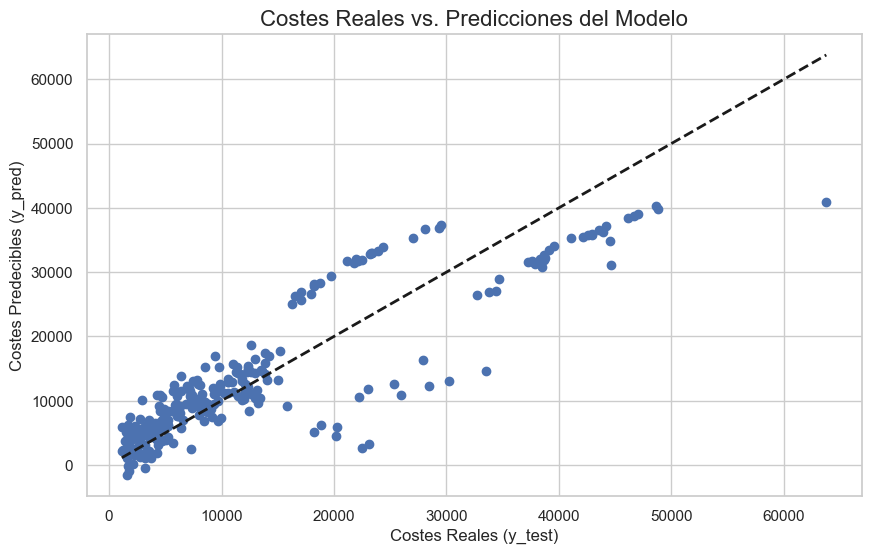

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hacemos predicciones sobre el conjunto de test (datos que el modelo no ha visto)
y_pred = model.predict(X_test)

# Visualicemos qué tan cerca están las predicciones de la realidad
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Costes Reales (y_test)")
plt.ylabel("Costes Predecibles (y_pred)")
plt.title("Costes Reales vs. Predicciones del Modelo", fontsize=16)
# Dibujamos una línea de 45 grados. Si las predicciones fueran perfectas, todos los puntos caerían sobre esta línea.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

### Métricas de Error

- **MAE (Error Absoluto Medio):** Nos dice, en promedio, cuántos dólares se equivoca nuestra predicción. Es fácil de interpretar.
- **RMSE (Raíz del Error Cuadrático Medio):** Similar al MAE, pero como eleva los errores al cuadrado, penaliza mucho más los errores grandes.
- **$R^2$ (R-cuadrado):** Nos dice qué porcentaje de la variación de los costes es explicado por el modelo. Va de 0 a 1 (o incluso negativo). Un valor más cercano a 1 es mejor.

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Error Absoluto Medio): ${mae:,.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): ${rmse:,.2f}")
print(f"R-cuadrado (R²): {r2:.2f}")

MAE (Error Absoluto Medio): $4,181.19
RMSE (Raíz del Error Cuadrático Medio): $5,796.28
R-cuadrado (R²): 0.78


### Interpretación de Coeficientes
¿Qué ha aprendido el modelo? ¿Qué variables considera más importantes?

In [12]:
# Creamos un DataFrame para ver los coeficientes de forma ordenada
coeficientes = pd.DataFrame(model.coef_, X.columns, columns=['Coeficiente'])
print("Intercepto del modelo (Beta_0):", model.intercept_)
print("\nCoeficientes de las variables:")
print(coeficientes)

# Interpretación: Por cada año que una persona envejece ('age'), el coste de su seguro aumenta en ~$256, si todo lo demás se mantiene constante.
# ¡Ser fumador ('smoker_yes') dispara los costes en casi $24,000!

Intercepto del modelo (Beta_0): -11931.21905032666

Coeficientes de las variables:
                   Coeficiente
age                 256.975706
bmi                 337.092552
children            425.278784
sex_male            -18.591692
smoker_yes        23651.128856
region_northwest   -370.677326
region_southeast   -657.864297
region_southwest   -809.799354


---
##  EJERCICIO EN CLASE: Regresión Lineal Simple

Ahora es tu turno. La intuición y la matriz de correlación nos dijeron que `bmi` (Índice de Masa Corporal) podría ser un predictor. Vamos a investigarlo por sí solo.

**Tareas:**
1.  **Define tus variables `X_simple` e `y_simple`**. `X_simple` debe ser únicamente la columna `bmi` del dataframe `df_encoded`. `y_simple` sigue siendo `charges`.
2.  **Divide los datos** en conjuntos de entrenamiento y prueba (`train_test_split`). Usa un `test_size=0.2` y `random_state=42`.
3.  **Crea y entrena un nuevo modelo** de `LinearRegression`.
4.  **Realiza predicciones** sobre el conjunto de prueba.
5.  **Calcula el R-cuadrado ($R^2$)** del modelo. ¿Qué tan bueno es comparado con el modelo múltiple que hicimos antes?
6.  **Visualiza el resultado**: Dibuja un `scatterplot` con los datos de prueba (`X_test_simple`, `y_test_simple`) y superpón la línea de regresión que ha aprendido tu modelo.

In [73]:
# 1. Define X_simple e y_simple
X_simple = df_encoded[["bmi"]]
y_simple = df_encoded["charges"]

In [79]:
# 2. Divide los datos
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.99, random_state=42)

In [80]:
# 3. Crea y entrena un nuevo modelo
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [81]:
# 4. Realiza predicciones
y_pred = model.predict(X_test)

In [82]:
# 5. Calcula el R-cuadrado
r2 = r2_score(y_test, y_pred)
print(f"R-cuadrado (R²): {r2:.2f}")

R-cuadrado (R²): -0.48


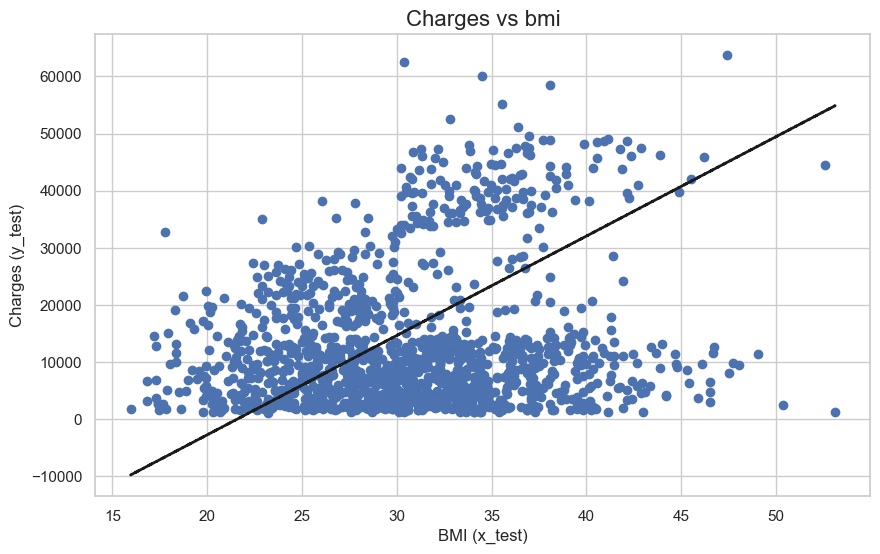

In [85]:
# 6. Visualiza el resultado
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test)
plt.xlabel("BMI (x_test)")
plt.ylabel("Charges (y_test)")
plt.title("Charges vs bmi", fontsize=16)
# Dibujamos una línea de 45 grados. Si las predicciones fueran perfectas, todos los puntos caerían sobre esta línea.
plt.plot(X_test, y_pred, 'k--', lw=2)
plt.show()

---
## Preguntas de recap – Sesión 1 (Regresión Simple)

1. ¿Qué mide el coeficiente de una regresión lineal simple?  
2. ¿Qué significa el intercepto (ordenada en el origen)?  
3. ¿Qué nos indica el R² de un modelo?  
4. Si al ajustar una regresión obtenemos un coeficiente negativo, ¿cómo lo interpretarías?

---


---
##  EJERCICIO PARA LA PRÓXIMA SESIÓN: Un Modelo Más Simple

El modelo con todas las variables (`R² ≈ 0.78`) es mucho mejor que el que solo usa `bmi`. Pero en el mundo real, la simplicidad es una virtud. Un modelo con menos variables es más fácil de explicar y mantener.

**Tu misión:**
Construye y evalúa un modelo de regresión lineal múltiple usando **únicamente un subconjunto de variables** que, a tu juicio (y según el heatmap), son las más importantes: `age`, `bmi` y `smoker_yes`.

**Pasos:**
1.  Prepara tu `X_reducido` seleccionando solo esas tres columnas del dataframe `df_encoded`. La `y` no cambia.
2.  Divide los datos en entrenamiento y prueba (`random_state=42`).
3.  Entrena el modelo de regresión lineal.
4.  Realiza una **evaluación completa**: calcula el MAE, RMSE y $R^2$.
5.  Crea la **visualización** de predicciones vs. valores reales para este nuevo modelo.

**--- Preguntas para la Reflexión ---**

**Responde a estas preguntas en una celda de texto (Markdown) al final de tu notebook:**

1.  **Comparación de Modelos:** Compara el $R^2$ y el MAE de este modelo reducido con el del modelo que usaba *todas* las variables. ¿Cuánta precisión (en dólares de error promedio) hemos "sacrificado" a cambio de un modelo más simple?
2.  **Decisión de Negocio:** Imagina que tienes que presentarle uno de los dos modelos (el completo vs. el reducido) a tu manager. ¿Cuál elegirías y por qué? Justifica tu respuesta pensando en el equilibrio entre rendimiento, simplicidad y explicabilidad.
3.  **Análisis Crítico:** Viendo el gráfico de predicciones vs. realidad de tu modelo reducido, ¿en qué zona parece fallar más? ¿Predice bien los costes muy altos o los muy bajos? ¿Por qué crees que ocurre esto, basándote en las variables que has usado?

In [ ]:
# 1. Prepara X_reducido e y
# TU CÓDIGO AQUÍ


In [ ]:
# 2. Divide los datos
# TU CÓDIGO AQUÍ

In [ ]:
# 3. Entrena el modelo
# TU CÓDIGO AQUÍ


In [ ]:
# 4. Evalúa el modelo (métricas)
# TU CÓDIGO AQUÍ

In [ ]:
# 5. Visualiza el resultado
# TU CÓDIGO AQUÍ

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas)*

---
## Preguntas de recap – Sesión 2 (Regresión Múltiple)

1. ¿Cómo interpretas el coeficiente de una variable en una regresión múltiple?  
2. ¿Por qué puede cambiar el valor de un coeficiente cuando añadimos nuevas variables al modelo?  
3. ¿Qué significa que un modelo esté sobreajustado (overfitting)?  
4. ¿Qué ventajas tiene evaluar un modelo con métricas como MAE, RMSE además de R²?
---


---
## Bonus Task Opcional

1. Carga un dataset distinto (por ejemplo, `sklearn.datasets.load_diabetes()` o uno que elijas tú).  
2. Ajusta una regresión múltiple con al menos 3 variables predictoras.  
3. Evalúa el modelo usando R² y RMSE.  
4. Interpreta qué variable parece tener más influencia en la predicción.  

Si quieres ir más allá: prueba a estandarizar las variables y compara los coeficientes.
---
